# Monte Carlo Portfolio Risk Management: VaR, Expected Shortfall & Stress Testing

## Overview

This project develops a quantitative portfolio risk-management framework using historical market data and Monte Carlo simulation.

The primary objective is to answer a practical financial risk question:

> **How much could a portfolio lose under normal and extreme market conditions, which assets contribute most to portfolio risk, and how can these measurements support risk-management decisions?**

The project uses a hypothetical ₱1 billion multi-asset portfolio and implements:

* Historical Value at Risk (VaR)
* Historical Expected Shortfall (ES)
* Monte Carlo simulation
* Monte Carlo VaR
* Monte Carlo Expected Shortfall
* Portfolio volatility and covariance analysis
* Asset-level risk contribution
* Stress testing
* Portfolio allocation comparison
* Risk-limit monitoring

## Business Problem

Financial institutions and investment managers need to quantify potential losses in order to monitor portfolio risk, establish exposure limits, evaluate capital requirements, and understand the consequences of different portfolio allocations.

A simple portfolio return calculation does not provide enough information for these decisions.

This project therefore models the distribution of potential portfolio losses rather than focusing only on expected returns.

## Methodology

The workflow is:

1. Obtain historical market prices.
2. Calculate daily asset returns.
3. Estimate return covariance and correlations.
4. Construct the portfolio.
5. Generate hundreds of thousands of correlated Monte Carlo scenarios.
6. Convert simulated returns into portfolio losses.
7. Calculate 99% VaR.
8. Calculate 99% Expected Shortfall.
9. Analyze asset-level risk contribution.
10. Apply a hypothetical stress scenario.
11. Compare alternative portfolio allocations.
12. Monitor the portfolio against a predefined risk limit.

## Key Risk Measures

### Value at Risk

VaR estimates a loss threshold at a selected confidence level.

For example, a 99% one-day VaR of ₱30 million means that approximately 1% of modeled one-day outcomes produce losses greater than ₱30 million.

### Expected Shortfall

Expected Shortfall goes beyond VaR by measuring the average loss among outcomes in the extreme tail.

For example:

```text
99% VaR = ₱30M
99% ES  = ₱45M
```

The interpretation is that once losses enter the worst 1% region, their average magnitude is approximately ₱45 million.

## Why Monte Carlo Simulation?

Monte Carlo simulation is useful when portfolio risk depends on multiple assets, correlations, and complex distributions.

Instead of asking only what happened historically, the simulation generates a large number of possible future outcomes based on estimated statistical properties of the market.

The resulting loss distribution allows VaR and Expected Shortfall to be estimated from simulated scenarios.

## Business Decision Framework

The project's output is intended to support questions such as:

* Is the portfolio within its risk limit?
* Which assets contribute most to portfolio risk?
* How large could losses become during extreme scenarios?
* How does changing portfolio allocation affect tail risk?
* Should portfolio exposure or hedging be reviewed?
* How sensitive is the portfolio to severe market scenarios?

The model provides quantitative risk information; portfolio-management decisions remain dependent on the institution's objectives, constraints, risk appetite, and governance framework.

## Technologies

* Python
* NumPy
* Pandas
* SciPy
* Matplotlib
* Seaborn
* yfinance
* Monte Carlo Simulation
* Quantitative Risk Management
* Portfolio Analytics

## Important Modeling Limitations

This project is an educational and portfolio implementation rather than a production risk system.

The Monte Carlo model assumes that historical estimates of return behavior and covariance provide useful information about future outcomes. Real financial markets can exhibit fat tails, volatility clustering, regime changes, liquidity constraints, nonlinear derivative exposures, and changing correlations.

A production implementation would therefore consider additional approaches such as:

* historical simulation
* volatility models such as GARCH
* regime-switching models
* fat-tailed distributions
* filtered historical simulation
* copulas
* full revaluation for derivatives
* liquidity-adjusted risk
* scenario and reverse-stress testing
* backtesting and model validation

## Project Objective

The primary objective is not simply to calculate VaR.

It is to demonstrate how statistical modeling and simulation can transform market data into quantitative information that can be incorporated into a financial risk-management process.


## Install/import libraries

In [1]:
!pip -q install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.stats import norm

## Define the portfolio

We will create a hypothetical ₱1 billion portfolio. For demonstration purposes, we will use major liquid assets.

In [2]:
tickers = {
    "SPY": "US Equities",
    "TLT": "Long-Term Bonds",
    "GLD": "Gold",
    "QQQ": "Technology"
}

# Portfolio weights
weights = np.array([
    0.40,  # SPY
    0.25,  # TLT
    0.15,  # GLD
    0.20   # QQQ
])

portfolio_value = 1_000_000_000  # ₱1 billion

portfolio = pd.DataFrame({
    "Asset": list(tickers.keys()),
    "Description": list(tickers.values()),
    "Weight": weights
})

portfolio

,Asset,Description,Weight
0,SPY,US Equities,0.40
1,TLT,Long-Term Bonds,0.25
2,GLD,Gold,0.15
3,QQQ,Technology,0.20


Notice how the diversification of porfolio is not simply putted in a single asset. For this analysis, we allow diversification to become part of the risk analysis.

## Download market data

In [5]:
prices = yf.download(
    list(tickers.keys()),
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-02,125.150002,150.057251,235.369812,97.574020
2018-01-03,124.820000,151.515289,236.858536,98.040527
2018-01-04,125.459999,151.780441,237.856903,98.024963
2018-01-05,125.330002,153.304764,239.442017,97.745056
2018-01-08,125.309998,153.901215,239.879822,97.682869


We use historical prices to estimate the statistical properties if the assets.

## Calculate daily returns

In [6]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004781
2018-01-04,0.005127,0.001750,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002855
2018-01-08,-0.000160,0.003891,0.001828,-0.000636
2018-01-09,-0.004628,0.000061,0.002264,-0.013373


## Explore the data

In [7]:
summary = pd.DataFrame({
    "Annual Return": returns.mean() * 252,
    "Annual Volatility": returns.std() * np.sqrt(252),
    "Minimum Daily Return": returns.min(),
    "Maximum Daily Return": returns.max()
})

summary

,Annual Return,Annual Volatility,Minimum Daily Return,Maximum Daily Return
Ticker,,,,
GLD,0.156023,0.151352,-0.064269,0.048530
QQQ,0.205444,0.240512,-0.119788,0.120031
SPY,0.151407,0.194595,-0.109424,0.105019
TLT,-0.005556,0.157503,-0.066683,0.075196


## Visualize cumulative performance

In [8]:
cumulative_returns = (1+ returns).cumprod()

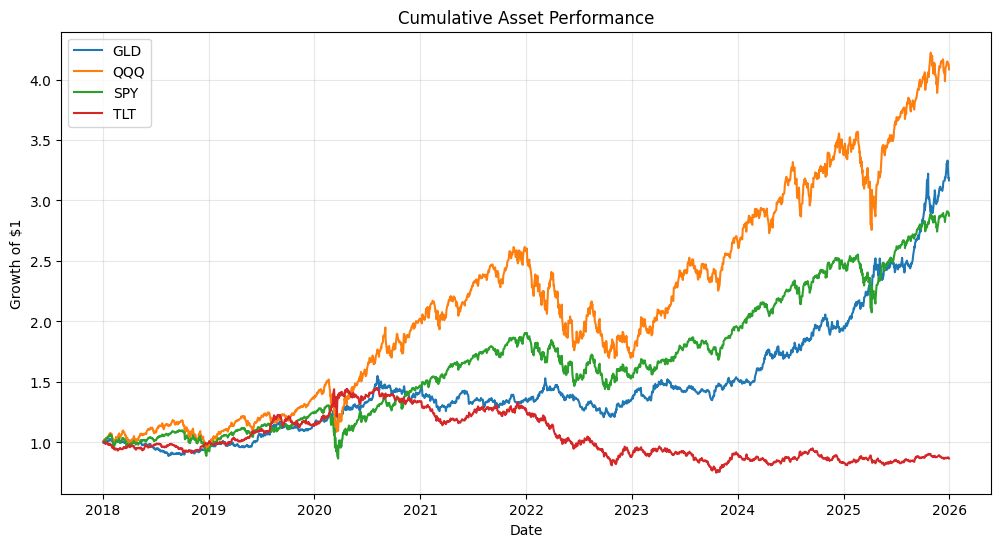

In [10]:
plt.figure(figsize=(12, 6))

for column in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[column],
        label=column
    )

plt.title("Cumulative Asset Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Examine correlations

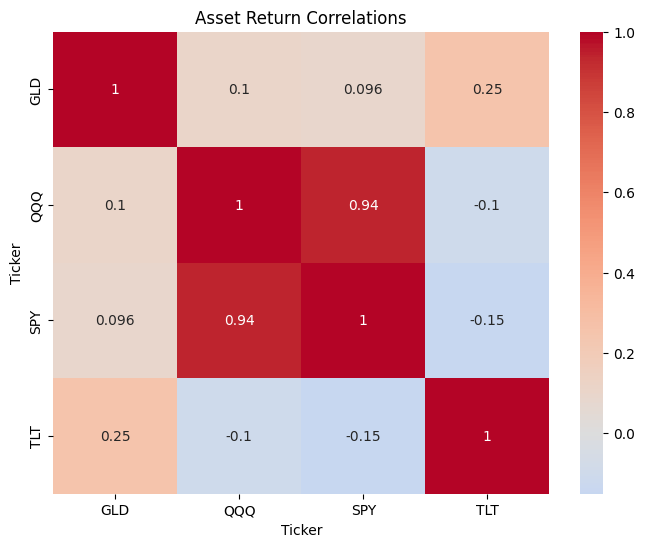

In [11]:
correlation_matrix = returns.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Asset Return Correlations")
plt.show()

The idea behind correlations is very important. Why does this matter?

Let's suppose both Asset A and Asset B falls 10%. If they are highly correlated, diversification provides less protection. But if we consider other scenario where Asset A falls and Asset B rises, the second asset can partially offset the first. As you can see, this is why portfolio risk is not simply the sum of individual asset risks.

## Calculate covariance matrix

In [12]:
covariance_matrix = returns.cov()

covariance_matrix

Ticker,GLD,QQQ,SPY,TLT
Ticker,,,,
GLD,0.000091,0.000015,0.000011,0.000024
QQQ,0.000015,0.000230,0.000174,-0.000015
SPY,0.000011,0.000174,0.000150,-0.000018
TLT,0.000024,-0.000015,-0.000018,0.000098


The covariance matrix captures how assets move together.

For portfolio variance:

$$
\sigma_p^2 = w^T \Sigma w
$$

where:

- $w$ = portfolio weights
- $\Sigma$ = covariance matrix
- $\sigma_p^2$ = portfolio variance

This equation is fundamental to portfolio risk management.

## Calculate historical portfolio returns

In [13]:
portfolio_returns = returns @ weights

portfolio_returns.describe()

,0
count,2010.000000
mean,0.000537
std,0.007401
min,-0.051990
25%,-0.003303
50%,0.000873
75%,0.004594
max,0.061734


The `@` operator performs matrix multiplication.

Conceptually, the portfolio return is:

$$
R_p = w_1R_1 + w_2R_2 + \cdots + w_nR_n
$$

where:

- $R_p$ = portfolio return
- $w_i$ = weight of asset $i$
- $R_i$ = return of asset $i$

In Python, this weighted sum can be calculated efficiently using the `@` operator:

$$
R_p = w^T R
$$

## Historical VaR

In [14]:
def historical_var(returns, confidence=0.99):
    """
    Calculate Historical Value at Risk.

    VaR represents the loss threshold corresponding
    to a specified confidence level.
    """

    return -np.percentile(
        returns,
        (1 - confidence) * 100
    )


historical_var_99 = historical_var(
    portfolio_returns,
    confidence=0.99
)

print(f"99% Historical VaR: {historical_var_99:.4%}")

99% Historical VaR: 1.9395%


This means that approximately 1% of historical daily observations had losses greater than 1.9395 %.

## Convert VaR to pesos

This is where the statistical models become a business metric.

In [15]:
historical_var_peso = (
    historical_var_99 *
    portfolio_value
)

print(
    f"99% Daily Historical VaR: "
    f"₱{historical_var_peso:,.2f}"
)

99% Daily Historical VaR: ₱19,394,906.68


This means that the estimated 99% one-day loss threshold is approximately ₱19,394,906.68.

## Expected Shortfall

In [16]:
def expected_shortfall(returns, confidence=0.99):

    var_threshold = np.percentile(
        returns,
        (1 - confidence) * 100
    )

    tail_losses = returns[
        returns <= var_threshold
    ]

    return -tail_losses.mean()


historical_es_99 = expected_shortfall(
    portfolio_returns,
    confidence=0.99
)

print(f"99% Historical ES: {historical_es_99:.4%}")

99% Historical ES: 2.6644%


Now, once we enter the worst 1% of outcomes, how large is the average loss?

The Expected Shortfall take into account tail-risk management.

Monte Carlo Simulation

In [18]:
np.random.seed(42)

n_simulations = 500_000

# Daily expected returns
mu = returns.mean().values

# Daily covariance matrix
cov_matrix = returns.cov().values

# Generate correlated random returns
simulated_asset_returns = np.random.multivariate_normal(
    mean=mu,
    cov=cov_matrix,
    size=n_simulations
)

# Calculate portfolio return for every simulation
simulated_portfolio_returns = (
    simulated_asset_returns @ weights
)

print(
    f"Generated {n_simulations:,} simulated "
    f"portfolio outcomes."
)

Generated 500,000 simulated portfolio outcomes.


“What could happen under the statistical characteristics we estimated from the market?”

We generate 500,000 possible outcomes.

## Convert returns to losses

In [19]:
simulated_losses = (
    -simulated_portfolio_returns
)

simulated_loss_peso = (
    simulated_losses *
    portfolio_value
)

simulated_loss_peso[:10]

array([ 3824579.90647221,  1107717.44103335, -6280160.79348372,
        7567145.06596273, -8932906.20492662,  8773444.33565519,
       -5436903.88529121, -3126896.2010981 ,  5068132.6821783 ,
        8126336.79703402])

## Monte Carlo VaR

In [20]:
confidence = 0.99

monte_carlo_var = np.percentile(
    simulated_losses,
    confidence * 100
)

monte_carlo_var_peso = (
    monte_carlo_var *
    portfolio_value
)

print(
    f"99% Monte Carlo VaR: "
    f"₱{monte_carlo_var_peso:,.2f}"
)

99% Monte Carlo VaR: ₱16,683,982.55


## Monte Carlo Expected Shortfall

In [21]:
tail_losses = simulated_losses[
    simulated_losses >= monte_carlo_var
]

monte_carlo_es = tail_losses.mean()

monte_carlo_es_peso = (
    monte_carlo_es *
    portfolio_value
)

print(
    f"99% Monte Carlo ES: "
    f"₱{monte_carlo_es_peso:,.2f}"
)

99% Monte Carlo ES: ₱19,190,941.75


## Visualize the simulated loss distribution

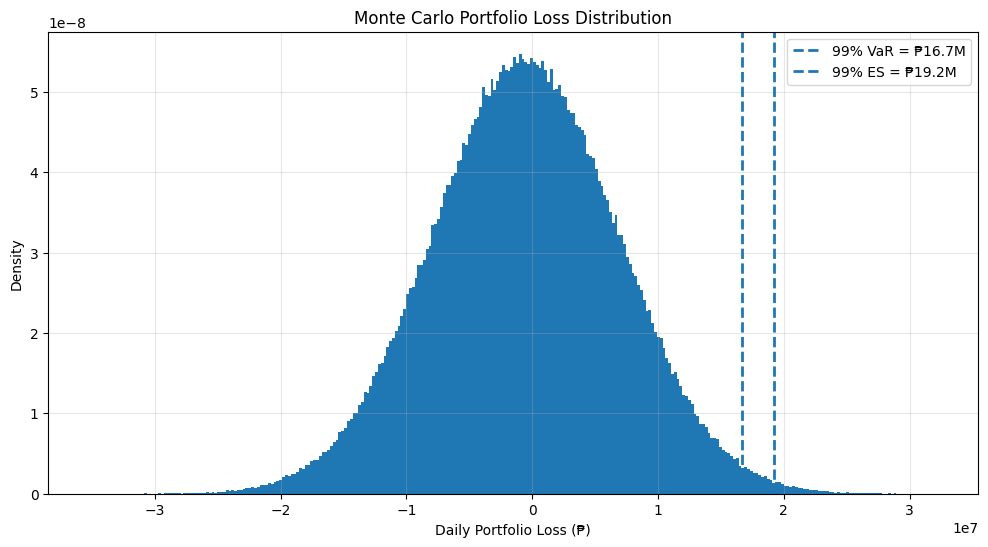

In [23]:
plt.figure(figsize=(12, 6))

plt.hist(
    simulated_loss_peso,
    bins=300,
    density=True
)

plt.axvline(
    monte_carlo_var_peso,
    linestyle="--",
    linewidth=2,
    label=f"99% VaR = ₱{monte_carlo_var_peso/1e6:.1f}M"
)

plt.axvline(
    monte_carlo_es_peso,
    linestyle="--",
    linewidth=2,
    label=f"99% ES = ₱{monte_carlo_es_peso/1e6:.1f}M"
)

plt.xlabel("Daily Portfolio Loss (₱)")
plt.ylabel("Density")
plt.title("Monte Carlo Portfolio Loss Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## VaR vs ES

In [24]:
risk_comparison = pd.DataFrame({
    "Metric": [
        "Historical VaR",
        "Historical ES",
        "Monte Carlo VaR",
        "Monte Carlo ES"
    ],
    "Loss": [
        historical_var_peso,
        historical_es_99 * portfolio_value,
        monte_carlo_var_peso,
        monte_carlo_es_peso
    ]
})

risk_comparison

,Metric,Loss
0,Historical VaR,1.939491e+07
1,Historical ES,2.664390e+07
2,Monte Carlo VaR,1.668398e+07
3,Monte Carlo ES,1.919094e+07


## Asset-level risk contribution

The question becomes:

 **Which assets are actually driving portfolio risk?**

We'll use a practical marginal-risk approach.

In [25]:
portfolio_volatility = np.sqrt(
    weights.T @ cov_matrix @ weights
)

marginal_contribution = (
    cov_matrix @ weights
) / portfolio_volatility

component_contribution = (
    weights * marginal_contribution
)

percentage_contribution = (
    component_contribution /
    portfolio_volatility
)

risk_contribution = pd.DataFrame({
    "Asset": list(tickers.keys()),
    "Portfolio Weight": weights,
    "Risk Contribution": percentage_contribution
})

risk_contribution

,Asset,Portfolio Weight,Risk Contribution
0,SPY,0.40,0.339799
1,TLT,0.25,0.394461
2,GLD,0.15,0.183145
3,QQQ,0.20,0.082596


## Visualize the risk contribution

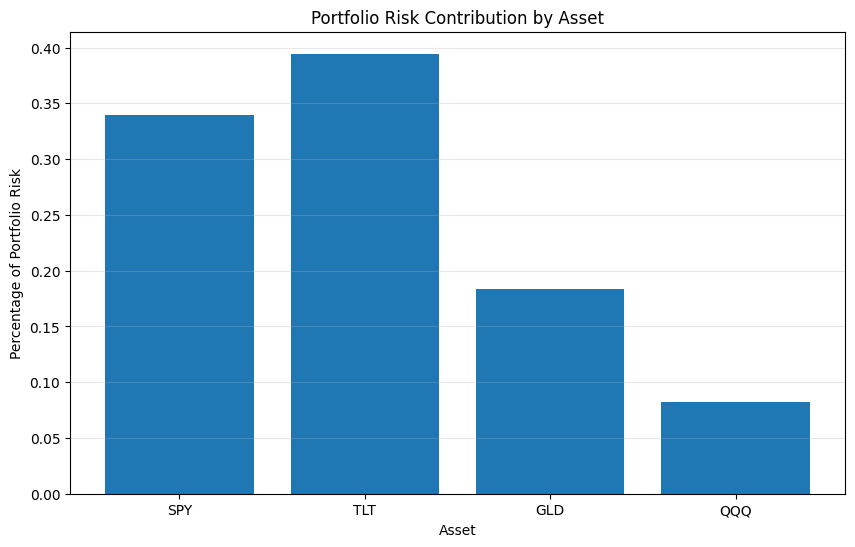

In [26]:
plt.figure(figsize=(10, 6))

plt.bar(
    risk_contribution["Asset"],
    risk_contribution["Risk Contribution"]
)

plt.title("Portfolio Risk Contribution by Asset")
plt.xlabel("Asset")
plt.ylabel("Percentage of Portfolio Risk")

plt.grid(axis="y", alpha=0.3)

plt.show()

This is directly relevant to portfolio risk management.

## Stress testing

Monte Carlo tells us about simulated distributions. But let's say risk manager are concern about what will happen if a severe market event occurs?

We want to construct a simple stress scenario.

In [27]:
stress_scenario = {
    "SPY": -0.15,
    "TLT": -0.05,
    "GLD":  0.05,
    "QQQ": -0.20
}

stress_returns = np.array([
    stress_scenario[ticker]
    for ticker in tickers.keys()
])

stress_portfolio_return = (
    stress_returns @ weights
)

stress_loss = (
    -stress_portfolio_return *
    portfolio_value
)

print(
    f"Stress Scenario Portfolio Loss: "
    f"₱{stress_loss:,.2f}"
)

Stress Scenario Portfolio Loss: ₱105,000,000.00


## Risk Summary

In [28]:
dashboard = pd.DataFrame({
    "Risk Metric": [
        "Portfolio Value",
        "99% Historical VaR",
        "99% Historical ES",
        "99% Monte Carlo VaR",
        "99% Monte Carlo ES",
        "Stress Test Loss"
    ],
    "Value": [
        portfolio_value,
        historical_var_peso,
        historical_es_99 * portfolio_value,
        monte_carlo_var_peso,
        monte_carlo_es_peso,
        stress_loss
    ]
})

dashboard

,Risk Metric,Value
0,Portfolio Value,1.000000e+09
1,99% Historical VaR,1.939491e+07
2,99% Historical ES,2.664390e+07
3,99% Monte Carlo VaR,1.668398e+07
4,99% Monte Carlo ES,1.919094e+07
5,Stress Test Loss,1.050000e+08


## We can add risk limits

This is where the project becomes much more business oriented. Suppose management wants to know:

> Maximum acceptable 99% daily VaR = 3% of the portfolio value.


In [29]:
risk_limit_percentage = 0.03

risk_limit_peso = (
    portfolio_value *
    risk_limit_percentage
)

print(
    f"Risk Limit: ₱{risk_limit_peso:,.2f}"
)

print(
    f"Monte Carlo VaR: ₱{monte_carlo_var_peso:,.2f}"
)

Risk Limit: ₱30,000,000.00
Monte Carlo VaR: ₱16,683,982.55


Now compare them:

In [30]:
if monte_carlo_var_peso > risk_limit_peso:

    print("ALERT: Portfolio VaR exceeds the risk limit.")

else:

    print("Portfolio VaR is within the risk limit.")

Portfolio VaR is within the risk limit.


## Portfolio allocation experiment

We can also test whether changing allocation changes risks

In [31]:
alternative_weights = np.array([
    0.30,  # SPY
    0.35,  # TLT
    0.15,  # GLD
    0.20   # QQQ
])

alternative_simulated_returns = (
    simulated_asset_returns @ alternative_weights
)

alternative_losses = (
    -alternative_simulated_returns
)

alternative_var = np.percentile(
    alternative_losses,
    99
)

alternative_es = alternative_losses[
    alternative_losses >= alternative_var
].mean()

print(
    f"Original 99% VaR: "
    f"₱{monte_carlo_var_peso:,.2f}"
)

print(
    f"Alternative 99% VaR: "
    f"₱{alternative_var * portfolio_value:,.2f}"
)

print(
    f"Original 99% ES: "
    f"₱{monte_carlo_es_peso:,.2f}"
)

print(
    f"Alternative 99% ES: "
    f"₱{alternative_es * portfolio_value:,.2f}"
)

Original 99% VaR: ₱16,683,982.55
Alternative 99% VaR: ₱18,261,643.84
Original 99% ES: ₱19,190,941.75
Alternative 99% ES: ₱21,011,896.10


In [32]:
results = pd.DataFrame({
    "Metric": [
        "Portfolio Value",
        "Monte Carlo VaR (99%)",
        "Monte Carlo ES (99%)",
        "Stress Test Loss",
        "VaR Risk Limit"
    ],

    "Amount (₱)": [
        portfolio_value,
        monte_carlo_var_peso,
        monte_carlo_es_peso,
        stress_loss,
        risk_limit_peso
    ]
})

results["Amount (₱)"] = results["Amount (₱)"].map(
    lambda x: f"₱{x:,.2f}"
)

results

,Metric,Amount (₱)
0,Portfolio Value,"₱1,000,000,000.00"
1,Monte Carlo VaR (99%),"₱16,683,982.55"
2,Monte Carlo ES (99%),"₱19,190,941.75"
3,Stress Test Loss,"₱105,000,000.00"
4,VaR Risk Limit,"₱30,000,000.00"


## What did we learn?

The Monte Carlo model generates a distribution of possible one-day portfolio outcomes using estimated asset return behavior and correlations.

From this distribution, we calculate:

$$ VaR_{99\%} $$

and

$$ ES_{99\%} $$

VaR provides a loss threshold at the selected confidence level, while ES measures the average loss in the tail beyond that threshold.

The analysis can then be used to monitor whether the portfolio remains within predefined risk limits.

The asset-level analysis additionally demonstrates that portfolio risk contribution is not necessarily proportional to portfolio allocation.

Finally, stress testing provides a scenario-based view of losses that may not be adequately represented by a statistical distribution alone.

## Portfolio Optimization

In [33]:
from scipy.optimize import minimize

We want to find portfolio weights that minimize 99% Expected Shortfall (ES). This means that we need to find an allocation that reduces the average loss in the worst 1% of simulated outcomes.

In [34]:
confidence = 0.99


def calculate_es(weights, simulated_asset_returns,
                 portfolio_value=1_000_000_000,
                 confidence=0.99):
    """
    Calculate the Monte Carlo Expected Shortfall
    for a given portfolio allocation.

    Parameters
    ----------
    weights : array
        Portfolio allocation for each asset.

    simulated_asset_returns : array
        Monte Carlo simulated asset returns.

    portfolio_value : float
        Total portfolio value.

    confidence : float
        Confidence level for ES.

    Returns
    -------
    float
        Expected Shortfall in pesos.
    """

    # Calculate portfolio return under every
    # simulated market scenario
    portfolio_returns = (
        simulated_asset_returns @ weights
    )

    # Convert returns into monetary losses
    losses = -portfolio_returns * portfolio_value

    # Calculate the VaR threshold
    var = np.percentile(
        losses,
        confidence * 100
    )

    # Keep only the worst 1% of outcomes
    tail_losses = losses[losses >= var]

    # Average loss inside the tail
    es = tail_losses.mean()

    return es

## Define the optimization constraint

In [35]:
n_assets = len(tickers)

# Initial allocation
initial_weights = np.ones(n_assets) / n_assets

# Every asset must have at least 5%
# and no more than 60% of the portfolio.
#
# These constraints are examples.
# In a real portfolio, the limits would come from
# investment policy and risk-management requirements.

bounds = [
    (0.05, 0.60)
    for _ in range(n_assets)
]

# The portfolio must be fully invested:
#
# w1 + w2 + ... + wn = 1

constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

The constraints are important.

Without them, an optimizer can sometimes produce allocations that are mathematically attractive but practically unreasonable.

We're saying:

$$
\sum_i w_i = 1
$$

and each asset must satisfy:

$$
0.05 \leq w_i \leq 0.60
$$

This means:

- The portfolio weights must add up to 100%.
- Each asset must have at least a 5% allocation.
- No single asset can have more than a 60% allocation.

## Run the optimization

In [36]:
optimization_result = minimize(
    fun=calculate_es,
    x0=initial_weights,
    args=(
        simulated_asset_returns,
        portfolio_value,
        confidence
    ),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "maxiter": 100,
        "ftol": 1e-6,
        "disp": True
    }
)

# Check whether optimization succeeded

print("Optimization successful:",
      optimization_result.success)

print("\nOptimization message:")
print(optimization_result.message)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 19996019.87532616
            Iterations: 5
            Function evaluations: 5
            Gradient evaluations: 1
Optimization successful: True

Optimization message:
Optimization terminated successfully


## Extract the optimal allocation

In [37]:
optimal_weights = optimization_result.x

optimal_allocation = pd.DataFrame({
    "Asset": list(tickers.keys()),
    "Original Weight": weights,
    "Optimal Weight": optimal_weights
})

optimal_allocation["Change"] = (
    optimal_allocation["Optimal Weight"]
    - optimal_allocation["Original Weight"]
)

optimal_allocation

,Asset,Original Weight,Optimal Weight,Change
0,SPY,0.40,0.25,-0.15
1,TLT,0.25,0.25,0.00
2,GLD,0.15,0.25,0.10
3,QQQ,0.20,0.25,0.05


## Calculate the optimized VaR and ES

Now we need to determine whether the new allocation actually changes the portfolio's risk.

In [38]:
optimal_portfolio_returns = (
    simulated_asset_returns @ optimal_weights
)

# Convert returns to losses
optimal_losses = (
    -optimal_portfolio_returns *
    portfolio_value
)

# 99% VaR
optimal_var = np.percentile(
    optimal_losses,
    99
)

# 99% ES
optimal_tail_losses = (
    optimal_losses[optimal_losses >= optimal_var]
)

optimal_es = optimal_tail_losses.mean()


print("ORIGINAL PORTFOLIO")
print("------------------")
print(f"99% VaR: ₱{monte_carlo_var_peso:,.2f}")
print(f"99% ES : ₱{monte_carlo_es_peso:,.2f}")

print("\nOPTIMIZED PORTFOLIO")
print("------------------")
print(f"99% VaR: ₱{optimal_var:,.2f}")
print(f"99% ES : ₱{optimal_es:,.2f}")

ORIGINAL PORTFOLIO
------------------
99% VaR: ₱16,683,982.55
99% ES : ₱19,190,941.75

OPTIMIZED PORTFOLIO
------------------
99% VaR: ₱17,383,672.15
99% ES : ₱19,996,019.88


##Measure the change in risk

In [39]:
var_change = (
    monte_carlo_var_peso - optimal_var
)

es_change = (
    monte_carlo_es_peso - optimal_es
)

var_change_pct = (
    var_change / monte_carlo_var_peso
)

es_change_pct = (
    es_change / monte_carlo_es_peso
)

print(
    f"VaR change: ₱{var_change:,.2f}"
)

print(
    f"VaR percentage change: {var_change_pct:.2%}"
)

print(
    f"ES change: ₱{es_change:,.2f}"
)

print(
    f"ES percentage change: {es_change_pct:.2%}"
)

VaR change: ₱-699,689.60
VaR percentage change: -4.19%
ES change: ₱-805,078.12
ES percentage change: -4.20%


##Visualization: Original vs Optimized allocation

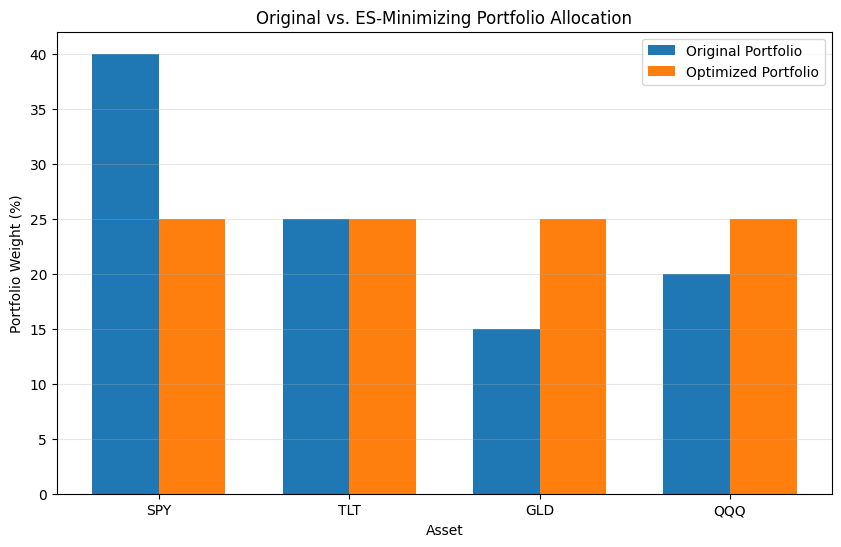

In [40]:
x = np.arange(len(tickers))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    weights * 100,
    width,
    label="Original Portfolio"
)

plt.bar(
    x + width / 2,
    optimal_weights * 100,
    width,
    label="Optimized Portfolio"
)

plt.xticks(
    x,
    list(tickers.keys())
)

plt.ylabel("Portfolio Weight (%)")
plt.xlabel("Asset")
plt.title(
    "Original vs. ES-Minimizing Portfolio Allocation"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

## Visualization: VaR and ES comparison

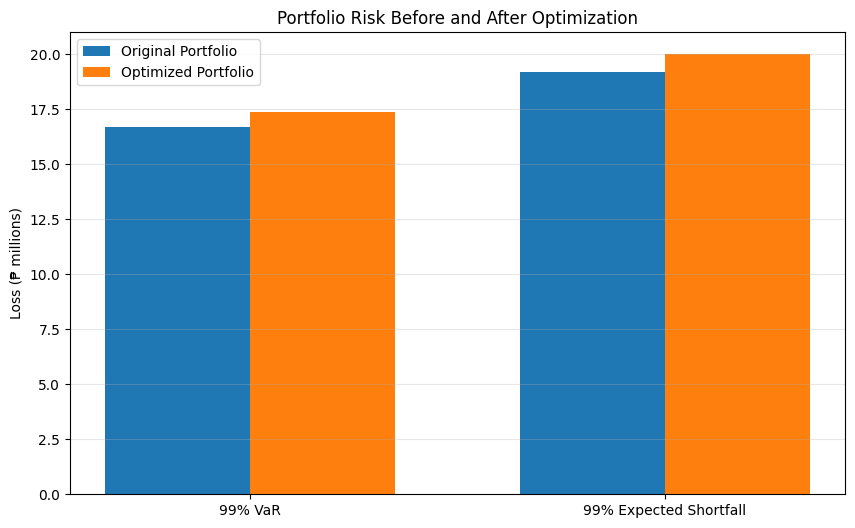

In [41]:
risk_metrics = pd.DataFrame({
    "Metric": [
        "99% VaR",
        "99% Expected Shortfall"
    ],

    "Original": [
        monte_carlo_var_peso / 1e6,
        monte_carlo_es_peso / 1e6
    ],

    "Optimized": [
        optimal_var / 1e6,
        optimal_es / 1e6
    ]
})

x = np.arange(len(risk_metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    risk_metrics["Original"],
    width,
    label="Original Portfolio"
)

plt.bar(
    x + width / 2,
    risk_metrics["Optimized"],
    width,
    label="Optimized Portfolio"
)

plt.xticks(
    x,
    risk_metrics["Metric"]
)

plt.ylabel("Loss (₱ millions)")
plt.title(
    "Portfolio Risk Before and After Optimization"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

##Visualization: efficient risk frontier

Instead of showing only one optimized portfolio, randomly generate thousands of portfolios and plot their risk.

In [42]:
np.random.seed(42)

n_random_portfolios = 5000

random_weights = np.random.dirichlet(
    np.ones(n_assets),
    size=n_random_portfolios
)

random_vars = []
random_ess = []

for w in random_weights:

    portfolio_simulated_returns = (
        simulated_asset_returns @ w
    )

    losses = (
        -portfolio_simulated_returns *
        portfolio_value
    )

    var = np.percentile(
        losses,
        99
    )

    es = losses[
        losses >= var
    ].mean()

    random_vars.append(var)
    random_ess.append(es)

random_vars = np.array(random_vars)
random_ess = np.array(random_ess)

Now visualize the relationship between VaR and ES.

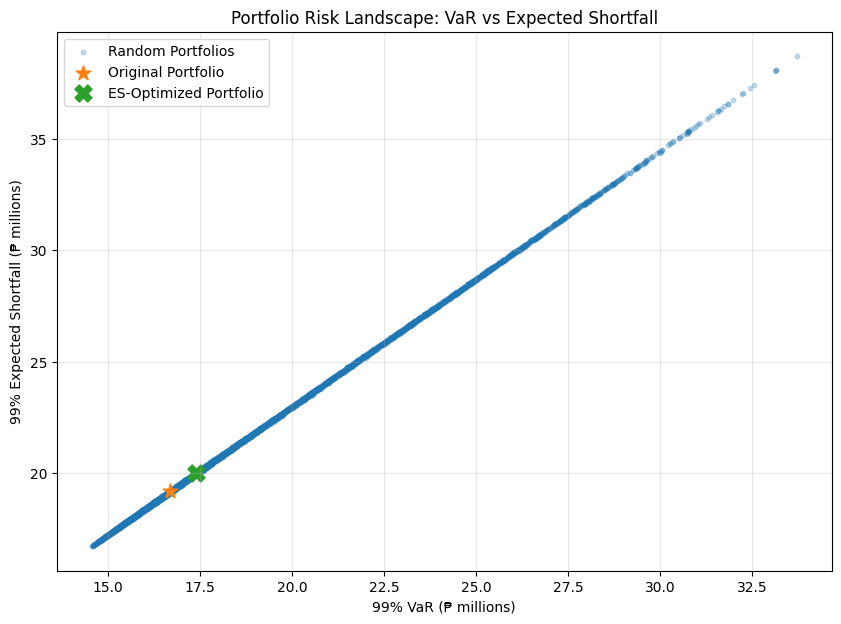

In [43]:
plt.figure(figsize=(10, 7))

plt.scatter(
    random_vars / 1e6,
    random_ess / 1e6,
    alpha=0.25,
    s=10,
    label="Random Portfolios"
)

plt.scatter(
    monte_carlo_var_peso / 1e6,
    monte_carlo_es_peso / 1e6,
    s=120,
    marker="*",
    label="Original Portfolio"
)

plt.scatter(
    optimal_var / 1e6,
    optimal_es / 1e6,
    s=150,
    marker="X",
    label="ES-Optimized Portfolio"
)

plt.xlabel("99% VaR (₱ millions)")
plt.ylabel("99% Expected Shortfall (₱ millions)")

plt.title(
    "Portfolio Risk Landscape: VaR vs Expected Shortfall"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

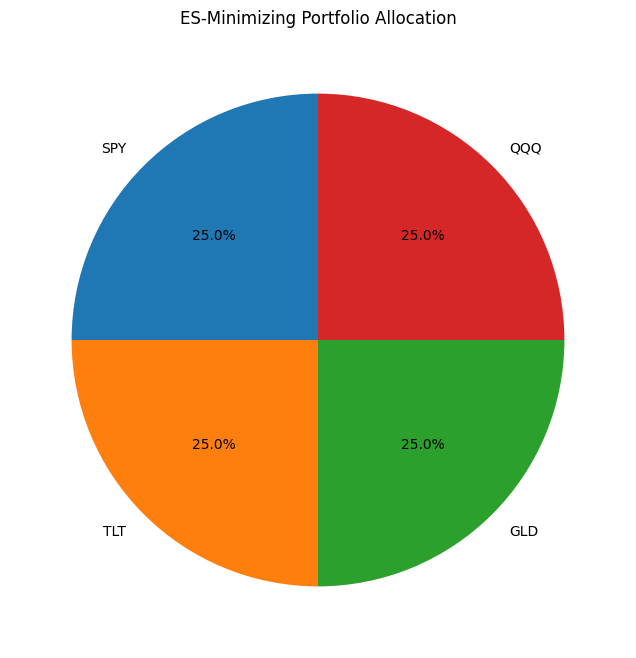

In [44]:
plt.figure(figsize=(8, 8))

plt.pie(
    optimal_weights,
    labels=list(tickers.keys()),
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "ES-Minimizing Portfolio Allocation"
)

plt.show()

In [45]:
optimization_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Value",
        "Original 99% VaR",
        "Optimized 99% VaR",
        "Original 99% ES",
        "Optimized 99% ES"
    ],

    "Value": [
        portfolio_value,
        monte_carlo_var_peso,
        optimal_var,
        monte_carlo_es_peso,
        optimal_es
    ]
})

optimization_summary

,Metric,Value
0,Portfolio Value,1.000000e+09
1,Original 99% VaR,1.668398e+07
2,Optimized 99% VaR,1.738367e+07
3,Original 99% ES,1.919094e+07
4,Optimized 99% ES,1.999602e+07
